In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [34]:

# 1. LOAD & CLEAN DATA
train = pd.read_csv("train_FD001.txt", sep=r"\s+", header=None)
columns = ['engine_id', 'cycle', 'op1', 'op2', 'op3'] + [f'sensor{i}' for i in range(1, 22)]
train.columns = columns


In [36]:
# 2. TARGET GENERATION (RUL)
# Calculate Remaining Useful Life and clip at 125 (standard for this dataset)
train['RUL'] = train.groupby('engine_id')['cycle'].transform('max') - train['cycle']
train['RUL'] = train['RUL'].clip(upper=125)

In [38]:
# 3. FEATURE ENGINEERING (Rolling Means)
# Adding rolling averages helps the Random Forest see "trends" over time
sensor_cols = [col for col in train.columns if 'sensor' in col]
for col in sensor_cols:
    train[f'{col}_rollmean'] = (
        train.groupby('engine_id')[col]
        .rolling(window=10)
        .mean()
        .reset_index(level=0, drop=True)
    )

# Use forward/backward fill to handle the NaN values created by the rolling window
train = train.ffill().bfill()

In [40]:
# 4. PREPARE DATA
feature_cols = train.columns.difference(['engine_id', 'cycle', 'RUL'])
X = train[feature_cols]
y = train['RUL']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
# 5. RANDOM FOREST MODEL
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [12]:
# 6. EVALUATION
rf_preds = rf_model.predict(X_test)
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_preds):.4f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):.4f}")

Random Forest MAE: 10.4563
Random Forest RMSE: 15.4461


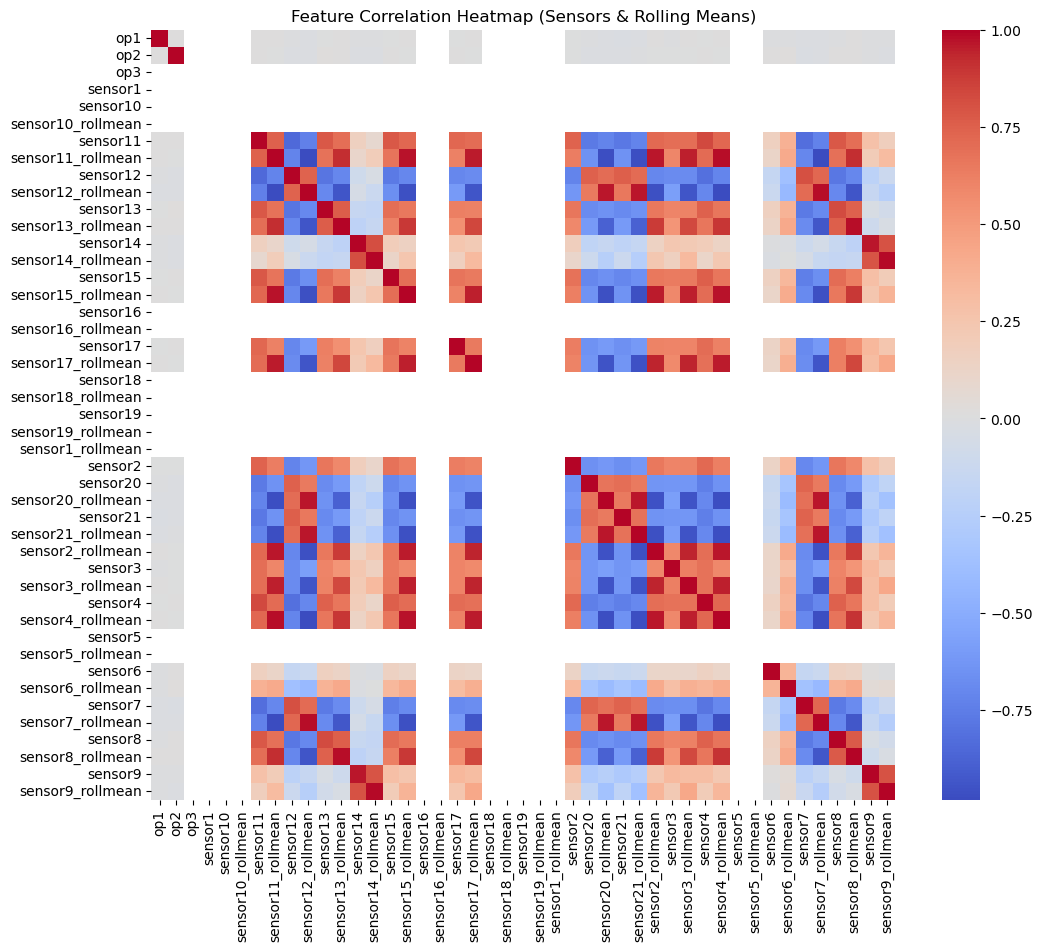

In [15]:
# --- 7. VISUALIZATIONS ---

# A. Feature Correlation Heatmap
# Helps identify which sensors are redundant or highly correlated
plt.figure(figsize=(12, 10))
sns.heatmap(train[feature_cols].corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap (Sensors & Rolling Means)")
plt.show()  

# B. Feature Importance Graph
# Shows which sensors 'predict' the failure most accurately
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-15:]  # Get top 15 features


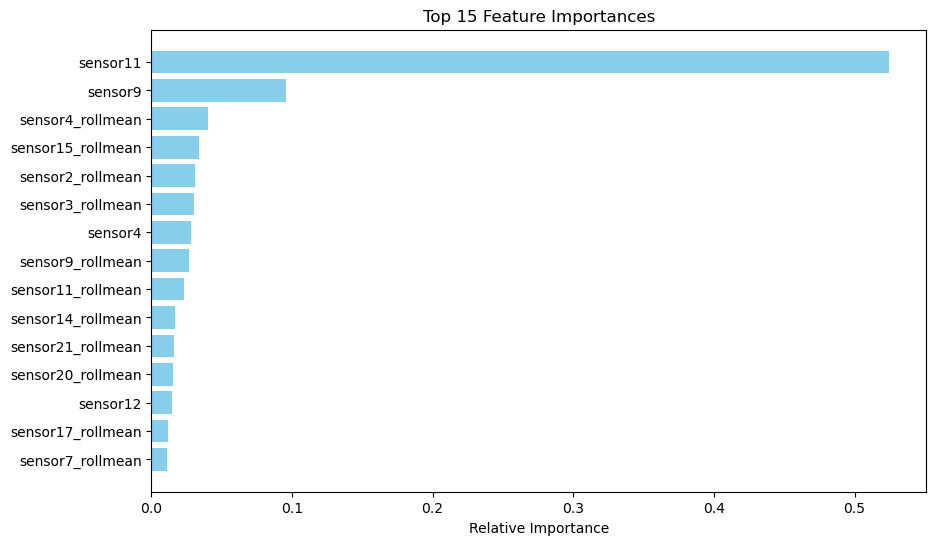

In [17]:
plt.figure(figsize=(10, 6))
plt.title('Top 15 Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

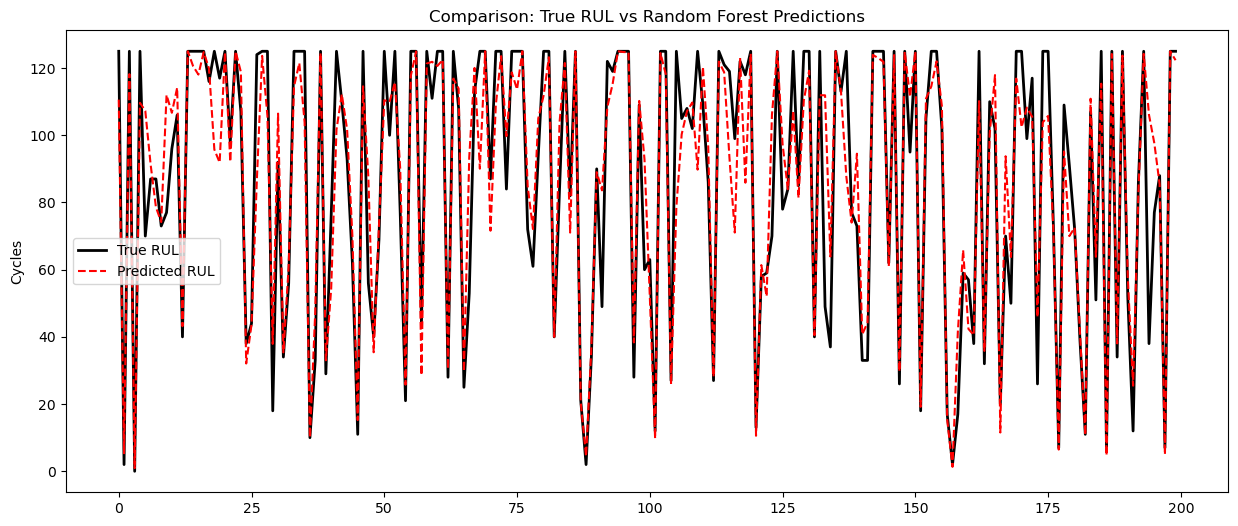

In [19]:
# C. Prediction vs True RUL (Sample)
# Visualizing the first 200 samples to see how closely the model tracks the real RUL
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:200], label="True RUL", color='black', linewidth=2)
plt.plot(rf_preds[:200], label="Predicted RUL", color='red', linestyle='--')
plt.title("Comparison: True RUL vs Random Forest Predictions")
plt.ylabel("Cycles")
plt.legend()
plt.show()

In [23]:
import joblib

# Save the model
joblib.dump(rf_model, 'random_forest_model.pkl')

# Save the feature columns so the website knows which sensors to look for
joblib.dump(feature_cols, 'feature_columns.pkl')

print("Model and features saved successfully!")

Model and features saved successfully!
